# Section 2.5



## Example 2.5.4


In [ ]:
n = 50
A = randn(n, n)
x = rand(n)
y = zeros(n)
for i in 1:n
    for j in 1:n
        y[i] += A[i, j] * x[j]    # 1 multiply, 1 add
    end
end


$$ \sum_{i=1}^n \sum_{j=1}^n 2 = \sum_{i=1}^n 2n = 2n^2. $$


In [ ]:
using BenchmarkTools
@belapsed A * x samples=100

In [ ]:
@btimed A*x

In [ ]:
n = 1000:1000:4000
t = []
for n in n
    A = randn(n, n)  
    x = randn(n)
    bench = @belapsed $A * $x samples=100
    push!(t, bench)
end

In [ ]:
using PrettyTables
pretty_table([n 1e3t];
     column_labels=["size", "time (msec.)"], backend=:html)

In [ ]:
t[4] / t[2]


$$
\frac{2(4000)^2}{2(2000)^2}=4.
$$



## Example 2.5.5

In [ ]:
using BenchmarkTools
n = 400:400:6000
t = []
for n in n
    A = randn(n, n)  
    x = randn(n)
    time = @belapsed $A * $x samples=50 evals=40
    push!(t, time)
end

In [ ]:
using Plots, LaTeXStrings
scatter(n, t, label="data", legend=false,
    xaxis=(:log10, L"n"), yaxis=(:log10, "elapsed time (sec)"),
    title="Timing of matrix-vector multiplications")

In [ ]:
plot!(n, t[end] * (n/n[end]).^2, l=:dash,
    label=L"O(n^2)", legend=:topleft)

## Example 2.5.6

In [1]:
using LinearAlgebra, BenchmarkTools
n = 400:400:4000
t = []
for n in n
    A = randn(n, n)  
    time = @belapsed lu($A) samples=50 evals=10
    push!(t, time)
end

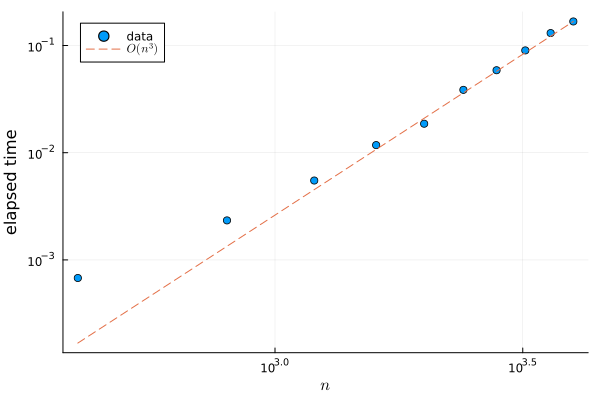

In [2]:
using Plots, LaTeXStrings
scatter(n, t, label="data", legend=:topleft,
    xaxis=(:log10, L"n"), yaxis=(:log10, "elapsed time"))
plot!(n, t[end]* (n/n[end]).^3, l=:dash, label=L"O(n^3)")